In [32]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## Cargar el dataset médico (Breastmnist)

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar.

Características del dataset en este ejercicio:
- Entrada:imágenes 2D de ultrasonido mamario en escala de grises, de tamaño 28 × 28 píxeles.
- Etiquetas: clasificación binaria.
- Clases: 0 = malignas , 1 = normal , benignas
- Particiones: 546 imágenes para entrenamiento, 78 para validación y 156 para prueba.

In [33]:
#adaptando dataset a breastmnist
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "breastmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info

{'python_class': 'BreastMNIST',
 'description': 'The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/breastmnist.npz?download=1',
 'MD5': '750601b1f35ba3300ea97c75c52ff8f6',
 'url_64': 'https://zenodo.org/records/10519652/files/breastmnist_64.npz?download=1',
 'MD5_64': '742edef2a1fd1524b2efff4bd7ba9364',
 'url_128': 'https://zenodo.org/records/10519652/files/breastmnist_128.npz?download=1',
 'MD5_128': '363e4b3f8d712e9b5de15470a2aaadf1',
 'url_224': 'https://zenodo.org/records/10519652/files/breastmnist_224.npz?download=1',
 'MD5_224

In [34]:
#transformacion basica
#T.ToTensor() convierte cada imagen en un tensor para que PyTorch pueda trabajar con ella.
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

#debe coincidir con nuestra info anterior...
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 546
Validation: 78
Test: 156


###Visualizar ejemplos

Ver ejemplos del dataset para entender su formato.

En la siguiente visualización se observan ejemplos de imágenes de ultrasonido mamario pertenecientes al conjunto de entrenamiento de BreastMNIST. Las imágenes se encuentran en escala de grises y han sido redimensionadas a 28 × 28 píxeles. La etiqueta 0 corresponde a casos malignos, mientras que la etiqueta 1 agrupa los casos normales y benignos. Debido a la baja resolución del dataset, las estructuras presentan un nivel de detalle limitado.

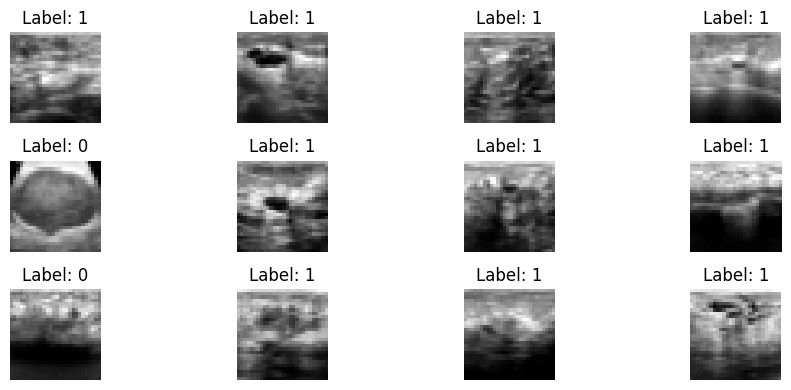

In [35]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i + 1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")
        plt.title(f"Label: {int(y.item())}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
show_batch(train_dataset)

##Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [37]:
#Tus 546 imágenes de entrenamiento no se meten todas juntas a la red. Se dividen en grupos llamados batches
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape

(torch.Size([32, 1, 28, 28]), torch.Size([32, 1]))

##1. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:

- Se utilizó inicialmente una arquitectura CNN compuesta por tres capas convolucionales con 16, 32 y 64 filtros, respectivamente. Durante el desarrollo se experimentó con una arquitectura de mayor capacidad, aumentando los filtros a 32, 64 y 128 e incorporando Batch Normalization y Dropout. Sin embargo, debido al reducido tamaño del conjunto BreastMNIST, esta modificación no produjo un comportamiento suficientemente estable en las métricas de validación.

In [60]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 1.1. Funciones de entrenamiento y evaluación

Para evaluar el desempeño del modelo en la clasificación de imágenes de BreastMNIST se utilizarán distintas métricas, ya que cada una permite analizar un aspecto diferente del rendimiento:

- Accuracy(indica la proporción de predicciones correctas respecto al total de imágenes evaluadas.)
- ROC-AUC(mide la capacidad del modelo para diferenciar entre las dos clases.)
- Matriz de confusión(permite observar cuántos casos fueron clasificados correctamente y en cuáles se produjeron errores.)
- Precision, Recall y F1-score(permiten analizar con mayor detalle el rendimiento por clase, especialmente cuando existe desbalance entre las categorías.)

In [61]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)
        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()
        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return acc, auc, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return float(np.mean(losses))

### 1.2. Entrenar el modelo desde cero

Para el entrenamiento de la CNN desde cero se mantuvo la arquitectura base propuesta, utilizando 8 épocas y el optimizador Adam con un learning rate de 0.001. Debido al desbalance presente en BreastMNIST, se incorporaron pesos de clase en la función de pérdida CrossEntropyLoss, asignando una mayor penalización a los errores correspondientes a la clase minoritaria. Con ello se busca reducir el sesgo hacia la clase mayoritaria y favorecer el aprendizaje de ambas clases durante el entrenamiento.

In [64]:
class_weights = torch.tensor(
    [1.857, 0.684],
    dtype=torch.float32
).to(device)

print("Pesos:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model_scratch.parameters(),lr=1e-3)

epochs = 8

history_scratch = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(
        model_scratch,
        train_loader,
        optimizer,
        criterion
    )
    val_acc, val_auc, _, _, _ = evaluate(
        model_scratch,
        val_loader
    )
    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | "f"train_loss={train_loss:.4f} | "f"val_acc={val_acc:.4f} | "f"val_auc={val_auc:.4f}")

Pesos: tensor([1.8570, 0.6840], device='cuda:0')
Epoch 01 | train_loss=0.6736 | val_acc=0.5385 | val_auc=0.6015
Epoch 02 | train_loss=0.6465 | val_acc=0.6667 | val_auc=0.6115
Epoch 03 | train_loss=0.6648 | val_acc=0.6667 | val_auc=0.6132
Epoch 04 | train_loss=0.6389 | val_acc=0.6282 | val_auc=0.6224
Epoch 05 | train_loss=0.6427 | val_acc=0.5385 | val_auc=0.6165
Epoch 06 | train_loss=0.6411 | val_acc=0.6410 | val_auc=0.6241
Epoch 07 | train_loss=0.6394 | val_acc=0.5513 | val_auc=0.6241
Epoch 08 | train_loss=0.6343 | val_acc=0.5641 | val_auc=0.6316


### 1.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


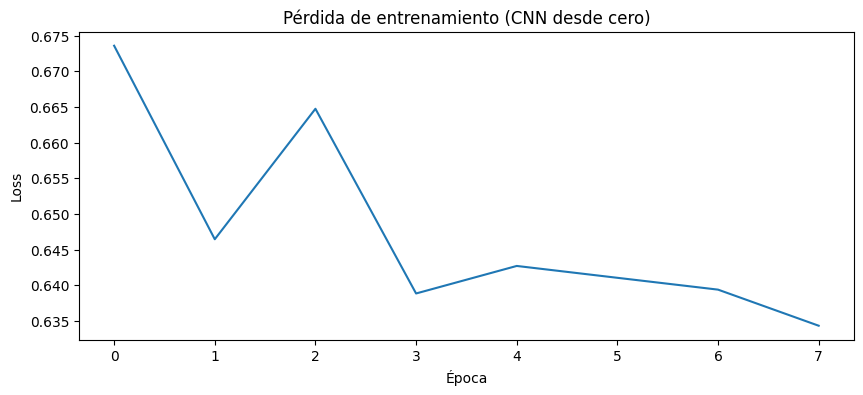

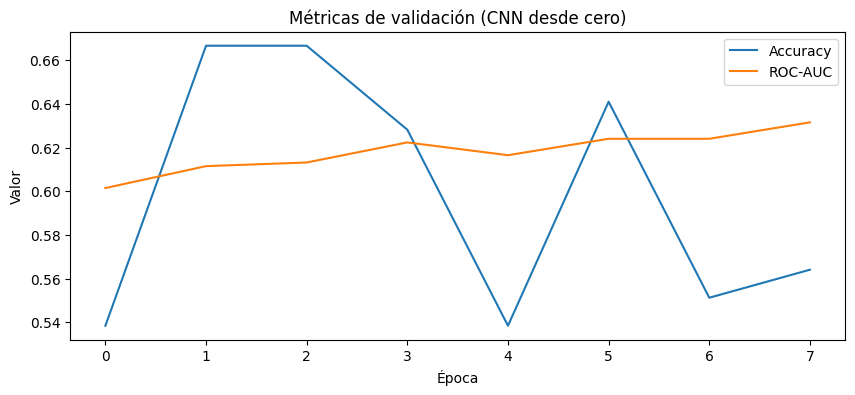

In [65]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"])
plt.title("Pérdida de entrenamiento (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()

### 1.4 Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.

In [68]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(
    model_scratch,
    test_loader
)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm

Test Accuracy: 0.6154
Test ROC-AUC: 0.6713

              precision    recall  f1-score   support

           0     0.3750    0.6429    0.4737        42
           1     0.8214    0.6053    0.6970       114

    accuracy                         0.6154       156
   macro avg     0.5982    0.6241    0.5853       156
weighted avg     0.7012    0.6154    0.6369       156



array([[27, 15],
       [45, 69]])

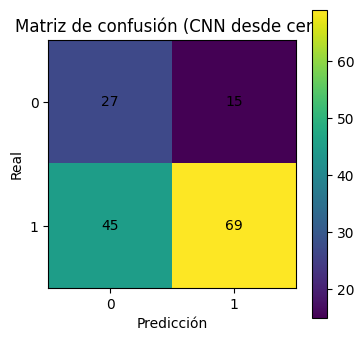

In [69]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)

plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.xticks([0, 1])
plt.yticks([0, 1])

for i in range(2):
    for j in range(2):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

## 2. Data Augmentation (aumento de datos)

Con el objetivo de mejorar la capacidad de generalización de la CNN, se aplicaron transformaciones moderadas únicamente al conjunto de entrenamiento. Se utilizaron pequeñas rotaciones de hasta 10° y traslaciones de hasta un 5%, manteniendo sin modificaciones los conjuntos de validación y prueba.

Para comparar el efecto del aumento de datos con la CNN entrenada previamente, se mantuvieron la misma arquitectura, función de pérdida ponderada y configuración del optimizador, incorporando como principal diferencia las transformaciones aleatorias sobre las imágenes de entrenamiento.

In [70]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

In [71]:
model_aug = SimpleCNN(
    num_classes=num_classes
).to(device)

criterion_aug = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer_aug = torch.optim.Adam(
    model_aug.parameters(),
    lr=1e-3
)

epochs = 8

history_aug = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        model_aug,
        train_loader_aug,
        optimizer_aug,
        criterion_aug
    )

    val_acc, val_auc, _, _, _ = evaluate(
        model_aug,
        val_loader
    )

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01 | train_loss=0.6939 | val_acc=0.6795 | val_auc=0.5681
Epoch 02 | train_loss=0.6923 | val_acc=0.7308 | val_auc=0.5739
Epoch 03 | train_loss=0.6872 | val_acc=0.6923 | val_auc=0.5798
Epoch 04 | train_loss=0.6899 | val_acc=0.6538 | val_auc=0.5815
Epoch 05 | train_loss=0.6851 | val_acc=0.6538 | val_auc=0.5840
Epoch 06 | train_loss=0.6774 | val_acc=0.6282 | val_auc=0.5865
Epoch 07 | train_loss=0.6600 | val_acc=0.6410 | val_auc=0.5906
Epoch 08 | train_loss=0.6956 | val_acc=0.5000 | val_auc=0.5965


In [72]:
#COMPARACION
# CNN sin Data Augmentation
test_acc, test_auc, _, _, _ = evaluate(
    model_scratch,
    test_loader
)

# CNN con Data Augmentation
test_acc_aug, test_auc_aug, _, _, _ = evaluate(
    model_aug,
    test_loader
)

print("Comparación en Test")
print("-" * 50)

print(
    f"Sin augmentation | "
    f"Accuracy = {test_acc:.4f} | "
    f"ROC-AUC = {test_auc:.4f}"
)

print(
    f"Con augmentation | "
    f"Accuracy = {test_acc_aug:.4f} | "
    f"ROC-AUC = {test_auc_aug:.4f}"
)

Comparación en Test
--------------------------------------------------
Sin augmentation | Accuracy = 0.6154 | ROC-AUC = 0.6713
Con augmentation | Accuracy = 0.5385 | ROC-AUC = 0.6418


## 3. Transfer Learning

In [74]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape

torch.Size([64, 3, 224, 224])

## 3.1 Construir ResNet18

In [75]:
resnet = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

in_features = resnet.fc.in_features

resnet.fc = nn.Linear(
    in_features,
    num_classes
)

resnet = resnet.to(device)

# Congelar toda la red
for name, param in resnet.named_parameters():
    param.requires_grad = False

# Entrenar únicamente la última capa
for param in resnet.fc.parameters():
    param.requires_grad = True

resnet

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 220MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [76]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    resnet.fc.parameters(),
    lr=1e-3
)

epochs = 4

history_tl_stage1 = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        resnet,
        train_loader_tl,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate(
        resnet,
        val_loader_tl
    )

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(
        f"Stage1 Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Stage1 Epoch 01 | train_loss=0.6130 | val_acc=0.7308 | val_auc=0.3893
Stage1 Epoch 02 | train_loss=0.6194 | val_acc=0.7308 | val_auc=0.4628
Stage1 Epoch 03 | train_loss=0.5599 | val_acc=0.7308 | val_auc=0.5380
Stage1 Epoch 04 | train_loss=0.5517 | val_acc=0.7308 | val_auc=0.6257


## 3.2 Fine-tuning

In [79]:
#descongelamos capa 4
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [
    p for p in resnet.parameters()
    if p.requires_grad
]

len(trainable_params)

17

In [80]:
optimizer = torch.optim.Adam(
    trainable_params,
    lr=1e-4
)

epochs = 4

history_tl_stage2 = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        resnet,
        train_loader_tl,
        optimizer,
        criterion
    )

    val_acc, val_auc, _, _, _ = evaluate(
        resnet,
        val_loader_tl
    )

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(
        f"Stage2 Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Stage2 Epoch 01 | train_loss=0.2344 | val_acc=0.8718 | val_auc=0.9190
Stage2 Epoch 02 | train_loss=0.1800 | val_acc=0.8974 | val_auc=0.9549
Stage2 Epoch 03 | train_loss=0.1559 | val_acc=0.9231 | val_auc=0.9440
Stage2 Epoch 04 | train_loss=0.1230 | val_acc=0.9103 | val_auc=0.9591


## 3.3 Evaluación final de Transfer Learning sobre TEST usando el modelo que acaba de terminar Stage 2:

In [81]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(
    resnet,
    test_loader_tl
)

print(f"Transfer Learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")

Transfer Learning | test_acc=0.8846 | test_auc=0.9190


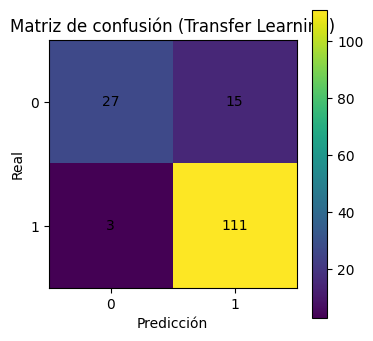

In [82]:
#matriz de confusion
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure(figsize=(4, 4))
plt.imshow(cm_tl)
plt.title("Matriz de confusión (Transfer Learning)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])

for i in range(2):
    for j in range(2):
        plt.text(
            j, i, cm_tl[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

## 3.4. Comparación global (resumen)

In [83]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.6154 | auc=0.6713
CNN desde cero (con aug)  | acc=0.5385 | auc=0.6418
Transfer learning (ResNet) | acc=0.8846 | auc=0.9190


## 4. Interpretabilidad básica: Grad-CAM

Grad-CAM permite visualizar mediante un mapa de calor las regiones de una imagen que tuvieron mayor influencia en la predicción realizada por la red neuronal. En esta sección se aplica una versión simplificada de Grad-CAM sobre la ResNet18 entrenada mediante Transfer Learning, con el objetivo de observar qué regiones de las imágenes de BreastMNIST son consideradas relevantes por el modelo.

In [84]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))

    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]

    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))

    cam = torch.sum(
        weights[:, None, None] * act,
        dim=0
    )

    cam = torch.relu(cam)

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


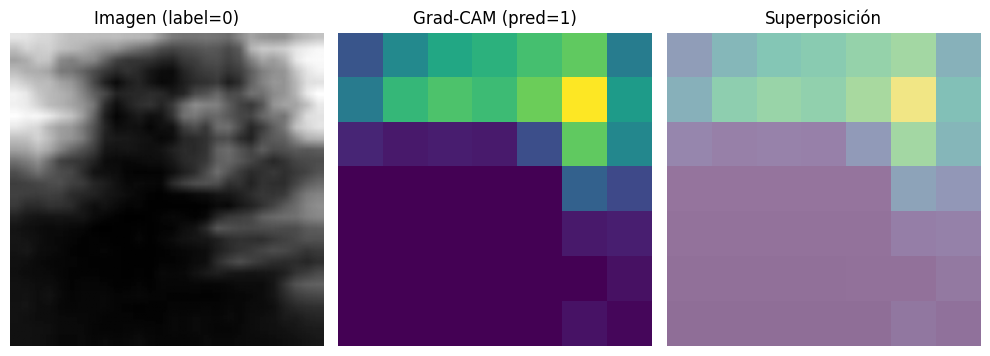

In [85]:
idx = 0

x, y = test_dataset_tl[idx]

cam, pred_class = grad_cam(
    resnet,
    x
)

img = x[0].numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()

In [86]:
#guardamos el modelo
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']